<font size=10>**TASK 2 - SENTIMENT ANALYSIS**</font> <a class="anchor" id='title'></a> 


*«notebook description»*

*How strong is the relationship between the polarity of a comments and its score?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#1)
- [2. Data](#2)
- [3. Sentiment Analysis](#3)
    - [3.1 Specific Data Preparation](#3_1)
    - [3.2 Model Implementation](#3_2)
    - [3.3 Model Evaluation](#3_3)
- [4. Professors Implementation of Sentiment Analysis](#4)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

In [1]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

In [2]:
# pip install vaderSentiment

In [3]:
import sys
import os
import pandas as pd
from scipy.stats import pearsonr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from nltk.tokenize import PunktSentenceTokenizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *
from sentiment_prep import *

# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="2"></a>
  
[Back to TOC](#toc)

In [4]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [5]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [6]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [7]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Sentiment Analysis**</font> <a class="anchor" id="3"></a>
  
[Back to TOC](#toc)


**How strong is the relationship between the polarity of a comments and its score?**

*(Sentiment Analysis with Correlation Matrix)*

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation</font> <a class="anchor" id="3_1"></a>
  
[Back to TOC](#toc)

In [8]:
dataset["preproc_content"] =\
      dataset["text"].map(lambda content : main_pipeline(content,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ))

In [9]:
sent_tokenizer = PunktSentenceTokenizer()

dataset["preproc_sentences"] =\
      dataset["text"].map(lambda content : [main_pipeline(sentence,
                                                            print_output=False,
                                                            no_stopwords=False,
                                                            lowercase=False,
                                                            lemmatized=False,
                                                            no_punctuation=False
                                                            ) for sentence in sent_tokenizer.tokenize(content)])

In [10]:
# Follow an example
print("Original Text Sample:\n")
print(dataset[['text']].sample(1, random_state=42).values)
print("\nPreprocessed Content Sample:\n")
print(dataset[['preproc_content']].sample(1, random_state=42).values)
print("\nPreprocessed Sentences Sample:\n")
print(dataset[['preproc_sentences']].sample(1, random_state=42).values)

Original Text Sample:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Preprocessed Content Sample:

[['Wife & I visited The Red Eyed Mule . The food was good . The biscuits are soft, tasty and just right.The service was great . Atmosphere clean and positive . The decorations on wall is very educational . Overall, enjoyed my breakfast experience at Red Eyed Mule . We plan to return.']]

Preprocessed Sentences Sample:

[[list(['Wife & I visited The Red Eyed Mule.', 'The food was good.', 'The biscuits are soft, tasty and just right.The service was great.', 'Atmosphere clean and positive.', 'The decorations on wall is very educational.', 'Overall, enjoyed my breakfast experience at Red Eyed Mule.', 'We plan to return.'])]]


In sentiment analysis, we **skip feature extraction** and **vectorization** steps, from the *text mining fluxogram*, because the tools we use (VADER and TextBlob) work directly with raw text.

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="3_2"></a>
  
[Back to TOC](#toc)

### <font color='#BFD72F' size=6>3.2.1 VADER Sentiment Analysis</font> <a class="anchor" id="3_2_1"></a>
  
[Back to TOC](#toc)

#### **3.2.1.1 Compound Score of Entire Review** <a class="anchor" id="3_2_1_1"></a>
*Sentiment score computed from the full text of each review.*

In [11]:
dataset["content_polarity_vader"] = dataset["preproc_content"].map(lambda review: vader_wrapper(review))

In [12]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nVader Polarity Sample:\n")
print(dataset[['content_polarity_vader']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Vader Polarity Sample:

[[0.9485]]


#### **3.2.1.2 Average Compound Score Across Sentences** <a class="anchor" id="3_2_1_2"></a>
*Mean sentiment score calculated from individual sentence-level analysis.*

In [13]:
dataset["mean_sentence_polarity_vader"] = dataset["preproc_sentences"].map(lambda review: vader_wrapper(review))

In [14]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Vader Polarity Sample Across Sentences:\n")
print(dataset[['mean_sentence_polarity_vader']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Vader Polarity Sample Across Sentences:

[[0.33127143]]


#### **3.2.1.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_1_3"></a>
*Scores Statistical comparison of both compound scoring approaches.*

In [15]:
pearson_r_vader, p_value_vader = pearsonr(dataset["content_polarity_vader"],dataset["mean_sentence_polarity_vader"])
print(f'Pearson correlation of content wise vader with mean sentences vader is: {pearson_r_vader}\nWhich means that, being so big, very few reviews have more than one sentence.')

Pearson correlation of content wise vader with mean sentences vader is: 0.8114668343234338
Which means that, being so big, very few reviews have more than one sentence.


### <font color='#BFD72F' size=6>3.2.2 TextBlob Sentiment Analysis</font> <a class="anchor" id="3_2_2"></a>
  
[Back to TOC](#toc)

#### **3.2.2.1 Polarity Score of Entire Review** <a class="anchor" id="3_2_2_1"></a>
*Sentiment polarity derived from the full review text.*

In [16]:
dataset["content_polarity_textblob"] = dataset["preproc_content"].map(lambda review: textblob_wrapper(review))

In [17]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nTextblob Polarity Sample:\n")
print(dataset[['content_polarity_textblob']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Textblob Polarity Sample:

[[0.30189394]]


#### **3.2.2.2 Average Polarity Across Sentences** <a class="anchor" id="3_2_2_2"></a>
*Mean polarity score based on sentence-level breakdown.*

In [18]:
dataset["mean_sentence_polarity_textblob"] = dataset["preproc_sentences"].map(lambda review: textblob_wrapper(review))

In [19]:
print("\nReview:\n")
print(dataset[['text']].sample(1, random_state=42).values)

print("\nAverage Textblob Polarity Sample Across Sentences:\n")
print(dataset[['mean_sentence_polarity_textblob']].sample(1, random_state=42).values)


Review:

[['Wife & I visited The Red Eyed Mule. The food was good.  The biscuits are soft, tasty and just right.The service was great. Atmosphere clean and positive. The decorations on wall is very educational. Overall, enjoyed my breakfast experience at Red Eyed Mule. We plan to return.']]

Average Textblob Polarity Sample Across Sentences:

[[0.27694805]]


#### **3.2.2.3 Correlation Between Full Review and Sentence-Level** <a class="anchor" id="3_2_2_3"></a>
*Polarity Evaluating consistency between aggregate and granular polarity scores.*

In [20]:
pearson_r_textblob, p_value_textblob = pearsonr(dataset["content_polarity_textblob"],dataset["mean_sentence_polarity_textblob"])
print(f'Pearson correlation of content wise textblob with mean sentences textblob is: {pearson_r_vader}\nWhich means that, being so big, very few reviews have more than one sentence')

Pearson correlation of content wise textblob with mean sentences textblob is: 0.8114668343234338
Which means that, being so big, very few reviews have more than one sentence


## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="3_3"></a>
  
[Back to TOC](#toc)

*VADER vs TextBlob: Performance Evaluation Using RMSE and MAPE*

In [21]:
scaler = MinMaxScaler()
#Vader
#The "reshape(-1,1)" is there to make sure that the column is fed as a 2D (4915 x 1) array
normalized_score = scaler.fit_transform(dataset["stars"].to_numpy().reshape(-1, 1))
normalized_polarity_vader = scaler.fit_transform(dataset["content_polarity_vader"].to_numpy().reshape(-1, 1))

#The "reshape(-1)" is there to flatten the 2D array into a 1D array
pearson_r_norm_vader, p_value_norm_vader = pearsonr(normalized_score.reshape(-1), normalized_polarity_vader.reshape(-1))
print(f'Pearson correlation of stars with vader is: {pearson_r_norm_vader}')

#TextBlob
normalized_polarity_textblob = scaler.fit_transform(dataset["content_polarity_textblob"].to_numpy().reshape(-1, 1))

pearson_r_norm_textblob, p_value_norm_textblob = pearsonr(normalized_score.reshape(-1), normalized_polarity_textblob.reshape(-1))
print(f'Pearson correlation of stars with textblob is: {pearson_r_norm_textblob}')

Pearson correlation of stars with vader is: 0.6770487767655596
Pearson correlation of stars with textblob is: 0.633631299937561


In [22]:
rmse_vader = mean_squared_error(normalized_score.reshape(-1), normalized_polarity_vader.reshape(-1))
mape_vader = mean_absolute_percentage_error(normalized_score.reshape(-1)+1, normalized_polarity_vader.reshape(-1)+1)

print("Pearon R: {}; RMSE: {}; MAPE: {}".format(round(pearson_r_norm_vader, 3), round(rmse_vader, 3), round(mape_vader, 3)))

Pearon R: 0.677; RMSE: 0.071; MAPE: 0.128


In [23]:
rmse_textblob = mean_squared_error(normalized_score.reshape(-1), normalized_polarity_textblob.reshape(-1))
mape_textblob = mean_absolute_percentage_error(normalized_score.reshape(-1)+1, normalized_polarity_textblob.reshape(-1)+1)

print("Pearson R: {}; RMSE: {}; MAPE: {}".format(round(pearson_r_norm_textblob, 3), round(rmse_textblob, 3), round(mape_textblob, 3)))

Pearson R: 0.634; RMSE: 0.087; MAPE: 0.16


In [24]:
pearson_r, p_value = pearsonr(normalized_polarity_vader.reshape(-1),normalized_polarity_textblob.reshape(-1))
print(f'Pearson correlation of vader with textblob is: {pearson_r}')

rmse_vader_textblob = mean_squared_error(normalized_polarity_vader.reshape(-1), normalized_polarity_textblob.reshape(-1))
mape_vader_textblob = mean_absolute_percentage_error(normalized_polarity_vader.reshape(-1)+1, normalized_polarity_textblob.reshape(-1)+1)

print("Pearson R: {}; RMSE: {}; MAPE: {}".format(round(pearson_r, 3), round(rmse_vader_textblob, 3), round(mape_vader_textblob, 3)))

Pearson correlation of vader with textblob is: 0.6336834260715166
Pearson R: 0.634; RMSE: 0.046; MAPE: 0.104


In [27]:
dataset["normalized_score"] = normalized_score.reshape(-1)
dataset["normalized_polarity_vader"] = normalized_polarity_vader.reshape(-1)
dataset["normalized_polarity_textblob"] = normalized_polarity_textblob.reshape(-1)
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
reviewsCount,53566.0,917.447355,1129.721892,5.0000,404.000000,644.000000,1051.250000,13268.0000
stars,53566.0,4.050498,1.448570,1.0000,3.000000,5.000000,5.000000,5.0000
content_polarity_vader,53566.0,0.520069,0.507781,-0.9973,0.361200,0.709700,0.896275,0.9990
mean_sentence_polarity_vader,53566.0,0.341398,0.333293,-0.9822,0.099917,0.397775,0.606914,0.9964
content_polarity_textblob,53566.0,0.360266,0.368009,-1.0000,0.100000,0.386111,0.620833,1.0000
mean_sentence_polarity_textblob,53566.0,0.328223,0.339234,-1.0000,0.075000,0.333333,0.556061,1.0000
normalized_score,53566.0,0.762625,0.362143,0.0000,0.500000,1.000000,1.000000,1.0000
normalized_polarity_vader,53566.0,0.760091,0.254361,0.0000,0.680509,0.855082,0.948542,1.0000
normalized_polarity_textblob,53566.0,0.680133,0.184004,0.0000,0.550000,0.693056,0.810417,1.0000


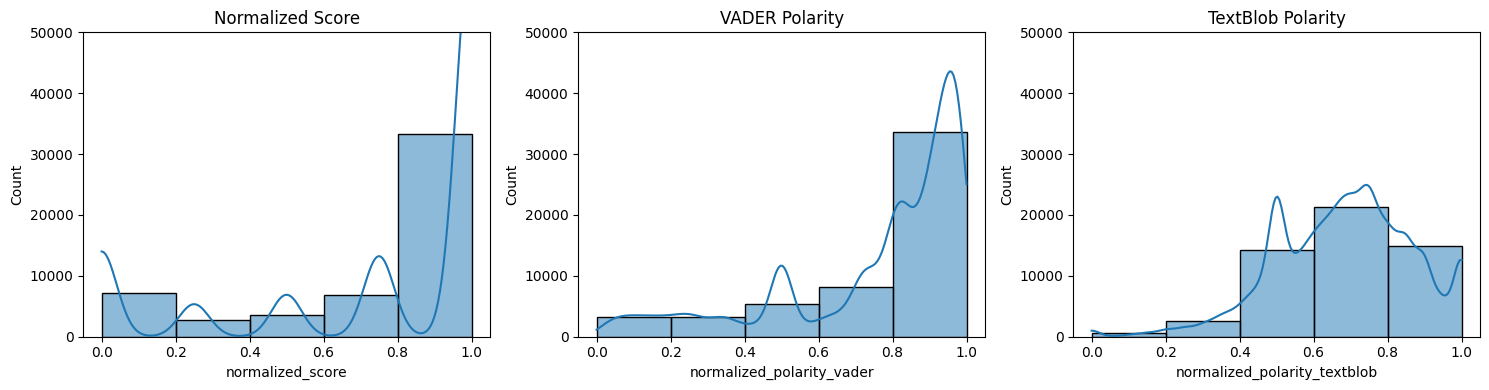

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 columns

sns.histplot(dataset["normalized_score"], kde=True, bins=5, ax=axes[0])
axes[0].set_ylim(0, 50000)
axes[0].set_title("Normalized Score")

sns.histplot(dataset["normalized_polarity_vader"], kde=True, bins=5, ax=axes[1])
axes[1].set_ylim(0, 50000)
axes[1].set_title("VADER Polarity")

sns.histplot(dataset["normalized_polarity_textblob"], kde=True, bins=5, ax=axes[2])
axes[2].set_ylim(0, 50000)
axes[2].set_title("TextBlob Polarity")

plt.tight_layout()
plt.show()

## <font color='#BFD72F' size=6>3.4 Answer the Question</font> <a class="anchor" id="3_4"></a>
  
[Back to TOC](#toc)

**How strong is the relationship between the polarity of a comments and its score?**

*(Sentiment Analysis with Correlation Matrix)*

Based on our analysis, **Vader** shows a slightly stronger correlation with review scores compared to TextBlob. 

Therefore, we focus on the correlation between the Vader polarity of a **full review** (rather than individual sentences) and its corresponding star rating, since most reviews contain only one or two sentences.  

- **Pearson correlation (R):** 0.677  
- **RMSE:** 0.071  
- **MAPE:** 0.128  

While the correlation is moderate rather than very strong, it indicates a noticeable relationship: more positive comments tend to have higher scores. 

The distribution of results also suggests that Vader captures the general sentiment trend in the reviews fairly consistently, even if it does not fully explain all the variation in ratings.